<a href="https://colab.research.google.com/github/CaelMarshall/Crime-Data-in-Leeds-April-2024-GEOG5990M-/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Gen Ai ACknowledgement

I have used Gen AI only for the specific purposes outlined in my acknowledgements

I acknowledge the use of Copilot (Microsoft, https://m365.cloud.microsoft/chat) to
compile my initial notes and to proofread my final draft before submission by the deadline.

In [ ]:

#provides the basemaps that can be used underneath spatial outputs
!pip install contextily
#Instalss spatial plotting tools
!pip install geoplot
#Installs features that allow the addition of a north arrow to maps made
!pip install git+https://github.com/pmdscully/geo_northarrow.git
# imports pandas which is used for data manipulation and gives it a shorter alias which is used in further code.
import pandas as pd
#imports numpy for numerical operations and gives it a shorter alias for use in further code
import numpy as np
#Imports geopandas which is used for spatial data and allows the plotting of maps, points and polygons based on
#what the data shows
import geopandas as gpd
# imports matplotlib for plotting graphs and gives it a shorter alias for use in further code. Plt is used to control
#factors such as titles, labels and display functions of graphs
import matplotlib.pyplot as plt
#Used for adding coordinate reference systems and projections
import pyproj
# imports systems used to add basemaps to spatial plots
import contextily as ctx
# imports seaborn which is used to make nicer statistics visualisations and gives it a shorter alias for use
# in further code.
import seaborn as sns
#importsfeatures that allow for spatial plottng
import geoplot as gplt
# imports features that allow for the manipulation of coordinate referance system
import geoplot.crs as gcrs
# imports a function to add a north arrow to the map
from geo_northarrow import add_north_arrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 63.8 MB/s eta 0:00:00
  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-d4nbcok1
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-d4nbcok1
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for geo_northarrow: filename=geo_northarrow-0.2.0a0-py3-none-any.whl size=14940 sha256=9879f0c9c0ca189379ff35c9537843b5fbcbea5943b2742d3842cb27d180ce7b
  Stored in directory: /tmp/pip-ephem-wheel-cache-brrxzsp2/wheels/d7/28/6c/cb006605c19bc4f58db715626f7113a6858d8c002e8c52fa80
Successfully built geo_northarrow


In [ ]:
#This code opens up a manual file uplode when running the notebook. By using this code i was able to manualy select
#the crime, imd, and lsoa boundry datasets and upload them manually
from google.colab import files
uploaded = files.upload()
#to check the files have been imported correctly and the data is now prepared for future use
#the following code is used to check the directory and make sure they are present
import os
os.listdir()

Saving LSOA_2021_EW_BGC_V5.cpg to LSOA_2021_EW_BGC_V5.cpg
Saving LSOA_2021_EW_BGC_V5.dbf to LSOA_2021_EW_BGC_V5.dbf
Saving LSOA_2021_EW_BGC_V5.prj to LSOA_2021_EW_BGC_V5.prj
Saving LSOA_2021_EW_BGC_V5.shp to LSOA_2021_EW_BGC_V5.shp
Saving LSOA_2021_EW_BGC_V5.shx to LSOA_2021_EW_BGC_V5.shx


['.config',
 'LSOA_2021_EW_BGC_V5.shx',
 'LSOA_2021_EW_BGC_V5.dbf',
 'IMD_BY_LSOA.csv',
 'LSOA_2021_EW_BGC_V5.shp',
 'LSOA_2021_EW_BGC_V5.cpg',
 'LSOA_2021_EW_BGC_V5.prj',
 'April_Crime_Data.csv',
 'sample_data']

In [ ]:
#this loads the LSOA 2021, IMD and Crime datasets
lsoa = gpd.read_file("LSOA_2021_EW_BGC_V5.shp")
Imd = pd.read_csv("IMD_BY_LSOA.csv")
crime = pd.read_csv("April_Crime_Data.csv")

In [ ]:
#This code shows the first 5 rows of both the IMD and Crime datasets
Imd.head()
crime.head()


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2024-04,West Yorkshire Police,West Yorkshire Police,-1.472961,53.599861,On or near Railway Walk,E01007439,Barnsley 001D,Anti-social behaviour,NaN,NaN
1,317bd0abb97f67a9b5e186e9895d13f4fc99d29f2c9f29...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.732999,53.545103,On or near Wood Royd Hill Lane,E01007426,Barnsley 027D,Violence and sexual offences,Unable to prosecute suspect,NaN
2,f3dc2030833b0bc107bc49bfc5182a73b95644e5ed7b3c...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.877569,53.943473,On or near Park Crescent,E01010646,Bradford 001A,Burglary,Investigation complete; no suspect identified,NaN
3,9b7f1084be073130cca59d4dfc1cc1cb7fd7909f7c78bb...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.875348,53.942581,On or near Sycamore Drive,E01010646,Bradford 001A,Criminal damage and arson,Unable to prosecute suspect,NaN
4,e5c5cd14ee4578b58ac1aa079623223e35e48ad173075d...,2024-04,West Yorkshire Police,West Yorkshire Police,-1.882138,53.944232,On or near Parking Area,E01010646,Bradford 001A,Other theft,Investigation complete; no suspect identified,NaN


In [ ]:
# shows the coloumn names, data types, and number of non null values in both datasets
Imd.info()
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33755 entries, 0 to 33754
Data columns (total 56 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   LSOA code (2021)                                                                                    33755 non-null  object 
 1   LSOA name (2021)                                                                                    33755 non-null  object 
 2   Local Authority District code (2024)                                                                33755 non-null  object 
 3   Local Authority District name (2024)                                                                33755 non-null  object 
 4   Index of Multiple Deprivation (IMD) Score                                                           33755 non-nu

In [ ]:
#shows the names of the colomns within the IMD dataset
Imd.columns

Index(['LSOA code (2021)', 'LSOA name (2021)',
       'Local Authority District code (2024)',
       'Local Authority District name (2024)',
       'Index of Multiple Deprivation (IMD) Score',
       'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)',
       'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)',
       'Income Score (rate)', 'Income Rank (where 1 is most deprived)',
       'Income Decile (where 1 is most deprived 10% of LSOAs)',
       'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)',
       'Employment Decile (where 1 is most deprived 10% of LSOAs)',
       'Education, Skills and Training Score',
       'Education, Skills and Training Rank (where 1 is most deprived)',
       'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)',
       'Health Deprivation and Disability Score',
       'Health Deprivation and Disability Rank (where 1 is most deprived)',
       'Health Dep

In [ ]:
# # Data downloaded from https://geoportal.statistics.gov.uk/maps/761ecd09b4124843b95511a242e2b1a1
#this code loads the 2021 LSOA boundry shapefile using geopandas and the dataset contains the actual polygon
#data for all LSOAs in England
shp =gpd.read_file('LSOA_2021_EW_BGC_V5.shp')
#to create a subset of just the study area a filter was applied to extract only the LSOAs that had a name containing
#the city 'leeds'
leeds_shp =shp.loc[shp['LSOA21NM'].str.contains('Leeds'),:]
#the filtered dataset is then saved for use in later coding
leeds_shp.to_file('Leeds.geojson')

In [ ]:
#this code provides an interactive map preview of the Leeds LSOAs
leeds_shp.explore()

In [ ]:
#shows the metadata for the file including number of LSOAs with leeds in their name, the amount of rows and coloums and object type
#for each column
leeds_shp.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 488 entries, 10719 to 33048
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   LSOA21CD   488 non-null    object  
 1   LSOA21NM   488 non-null    object  
 2   LSOA21NMW  0 non-null      object  
 3   BNG_E      488 non-null    int64   
 4   BNG_N      488 non-null    int64   
 5   LAT        488 non-null    float64 
 6   LONG       488 non-null    float64 
 7   GlobalID   488 non-null    object  
 8   geometry   488 non-null    geometry
dtypes: float64(2), geometry(1), int64(2), object(4)
memory usage: 38.1+ KB


In [ ]:
#checks the coordinate system of the boundry dataset so that we know what crs to change the other files to
#as they need to match to have correct analysis later
leeds_shp.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [ ]:
#This block converts the crime dataset from a standard dataframe to a geodataframe and creates
#point geomitries from the longitude and latitude column. This allows the crime data to be spatially aggrigated
#and plotted on the map of leeds later on. It was given a crs of 4326 as this is the universal standard
#when converting gps coordinates
crime_gdf = gpd.GeoDataFrame(
    crime, geometry=gpd.points_from_xy(crime.Longitude, crime.Latitude))
crime_gdf = crime_gdf.set_crs(epsg = 4326)
#the crs of crime data was then reprojected to match that of the Leeds Lsoa which means any spatial joins
#will now be accurate
crime_gdf = crime_gdf.to_crs(leeds_shp.crs)

In [ ]:
#This code does a spatial join containing the point data juat made and the polygon boundries of LSOAs
#the 'within' precidate ensures that only the crimes located inside of an LSOA polygon are matched up
crime_lsoa = gpd.sjoin(crime_gdf, leeds_shp, how="inner", predicate="within")

In [ ]:
#This block groups the joined datasets by the LSOA code using 'LSOA21CD' with size counting the number of incidents in each area,
#whilst then resenting the result into a clean dataframe with a new column called 'crime count' being added.
#the counts are then merged back into the boundries dataframe so that each LSOA has their associated total
#number of crimes. Finally 'fillna(0)'was used to ensure that LSOAs with no crime records are given a value of 0 instead of just missing
#data all together
crime_counts = crime_lsoa.groupby("LSOA21CD").size().reset_index(name="crime_count")
leeds_shp = leeds_shp.merge(crime_counts, on="LSOA21CD", how= "left")
leeds_shp["crime_count"] = leeds_shp["crime_count"].fillna(0)

In [ ]:
#this code merges the IMD dataset to the LSOA dataset which in turn adds deprivation scores to to each LSOA enabling comparison between crime levels
#and socioeconomic conditions
leeds_shp = leeds_shp.merge(Imd, left_on="LSOA21CD", right_on="LSOA code (2021)", how="left")

In [ ]:

#This code filters the dataset to identify LSOAs with more than 65 crimes
centre_lsoa=leeds_shp.loc[leeds_shp["crime_count"]> 65,:]

Text(0.5, 1.0, 'Crime Distribution in Leeds Centre')

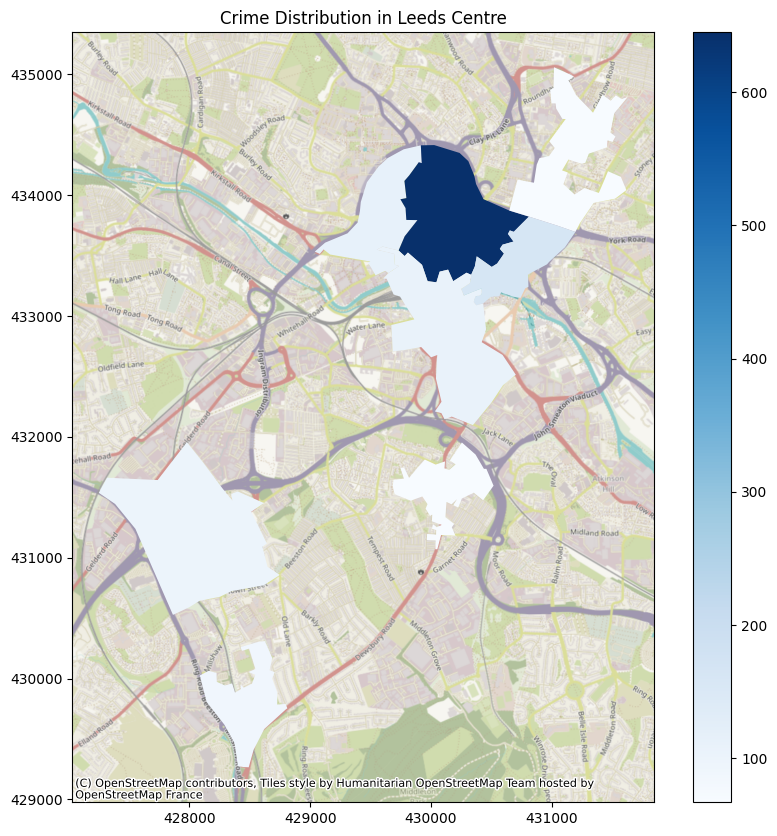

In [ ]:
#This block produces a choropleth map with the polygons coloured by crime level, with blue beimg used for the colour
#as it is colourblind friendly and is a sequential colourscheme. The map also has a legend to display the
#colour scale and allows for easy interpritation. A basemap was then added using the same crs as the LSOAs to ensure spatial
#uniformity and context. The map overall highlights the spatial concentration of crime in central Leeds.
f,ax = plt.subplots(1,figsize=(10, 10))
centre_lsoa.plot( ax=ax, column= "crime_count", cmap= "Blues",legend= True )
ctx.add_basemap(ax,crs= leeds_shp.crs)
plt.title("Crime Distribution in Leeds Centre")

Text(0.5, 1.0, 'Crime Distribution in Leeds')

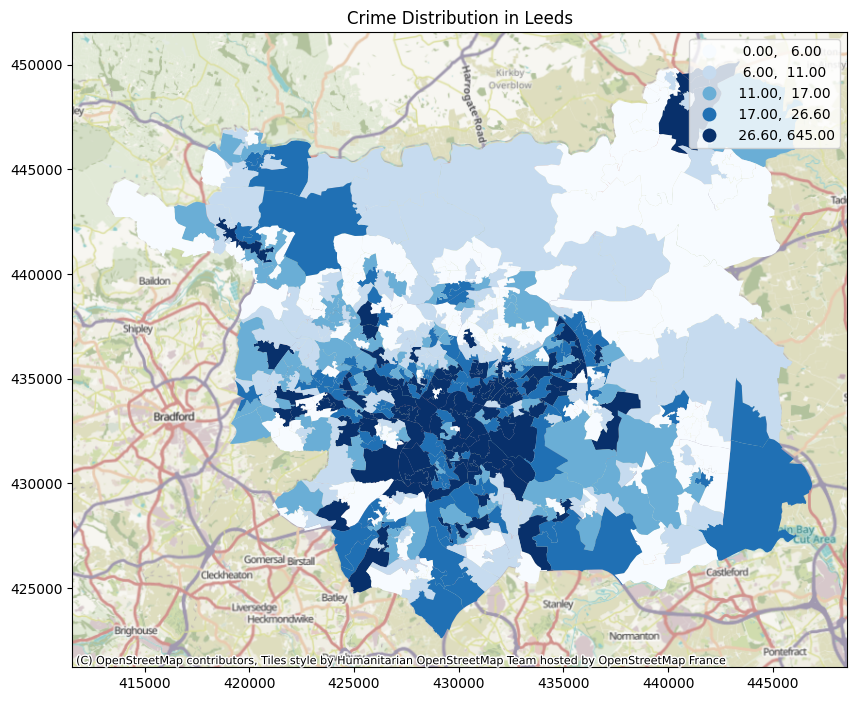

In [ ]:
#This block of code visualises crime counts across all the Leeds LSAOs with it being arranged in a quantiles fashion which
#devides the data into five equal sized groups ensuring fair colour distribution.This method is usefull when a dataset
#can be unevenly distributed. The title and basemap here improve readability and comunication for all readers.
f,ax = plt.subplots(1,figsize=(10, 10))
leeds_shp.plot( ax=ax, column= "crime_count", cmap= "Blues",scheme="quantiles",k=5,legend= True )
ctx.add_basemap(ax,crs= leeds_shp.crs)
plt.title("Crime Distribution in Leeds")

/tmp/ipykernel_31752/2462342411.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data= leeds_shp, x="Index of Multiple Deprivation (IMD) Score", y= "crime_count", palette='viridis', marker='o', s=40, alpha=0.7)


Text(0, 0.5, 'Crime Count')

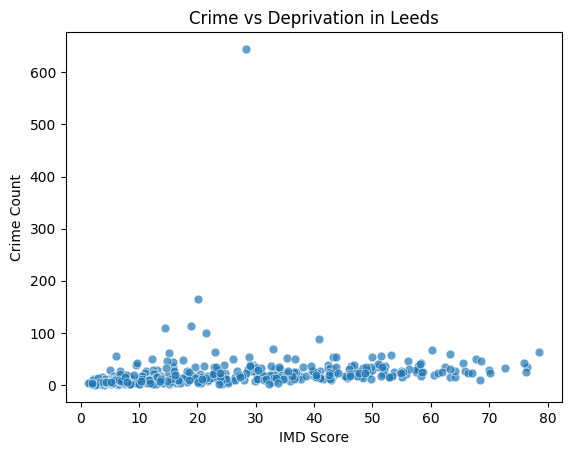

In [ ]:
#This scatterplot examines the relationship between crime counts and IMD score for the LSOAs. The use of the 'virdis' pallette makes sure that the colour scheme is
#uniform and clear despite the slight transparency that the individual points have. This visualisation helps identifywhether more deprived areas
#experience higher crime levels.
sns.scatterplot(data= leeds_shp, x="Index of Multiple Deprivation (IMD) Score", y= "crime_count", palette='viridis', marker='o', s=40, alpha=0.7)
plt.title("Crime vs Deprivation in Leeds")
plt.xlabel("IMD Score")
plt.ylabel("Crime Count")

In [ ]:
Analysis Introduction:
This study investigates the spatial distribution of crime across Leeds and
its relationship with socioeconomic deprivation as understanding where crime is concentrated, alongside the factors associated with its incline or decline, is
essential for informing effective police strategies and improving public safety. In particular, deprivation has been linked frequently to higher crime rates, making it
an important variable for spatial analysis. By using open-source data, including police record crime incidents and the index of multiple deprivation (IMD), this study applies
spatial data science techniques on python to analyse crime and deprivation patterns by Lower Layer Super Output Area (LSOA) levels. By combining point-based crime data with area-based
deprivation measures, the analysis aims to identify if more deprived areas experience higher levels of crime. The findings of this study aim to provide insights that could support
policy makers and local authorities in targeting police resources more effectively, contributing to safer and more equitable communities.


In [ ]:
Analysis Data:
This study utilises three open-source datasets to analyse the relationship between crime and deprivation in Leeds whereby crime data were obtained from the UK Police open data portal
and consists of recorded crime incidents for April 2024. The dataset included geographic coordinates (Longitude and Latitude), crime types and other attributes that allowed for each
incident to be spatially represented as a point. Socioeconomic conditions were measured using the IMD dataset for 2025, which provides a composite score of deprivation for each LSOA
in England. The IMD incorporates multiple dimensions including income, health, employment, education, and housing making it robust and reliable as an indicator of relative deprivation.
Spatial boundaries were defined using the 2021 LSOA boundary dataset for England and Wales meaning the polygons represented small geographic areas designed for statistical analysis and
enable reliable areas to be given to the point-based crime data.
Before carrying out the main analysis an exploratory data analysis was conducted to understand the structure, completeness and initial patterns in the datasets with IMD and crime data
 being explored with .head and .info to confirm key variables such as coordinates alongside LSOA codes and make sure they were formatted correctly without missing any major values.
 The LSOA dataset was used alongside .explore to produce a visually interactive map which confirmed the range of the study area. Through initial mapping and summary checks it was
 revealed that there was early evidence of spatial clustering around the centre of Leeds and that some LSOAs reported zero crimes which showed variation in the reporting data.


In [ ]:
Analysis Methods:
Initial preprocessing involved importing the required datasets and inspecting their structure using summary functions, like .info and .describe, to identify relevant variables and
potential data quality issues. The crime dataset was examined to ensure that latitude and longitude fields were formatted correctly as numeric values, and any missing or invalid entries
 were removed to retain analytical reliability. Alongside this, the IMD dataset was explored to identify the columns used within the dataset in order to find the corresponding LSOA codes
  that were required later for merging. In order to define the study area the LSOA boundry dataset was examined and filtered based on the polygons containing the name ‘Leeds’ which produced
  a geospatial dataset representing the study area which was used in further analysis.
With crime data being provided as point coordinates, they were converted into a Geodataframe to enable spatial analysis with the Coordinate reference system (CRS) being initially defined
 as EPSG:4326 which is the standard for longitude and latitude data (World Geodetic System, 1984) and was then reprojected to CRS 27700 which matched the LSOA boundary and allowed for
 seamless spatial alterations. Following this a spatial join was performed to assign each crime event to an LSOA based on geographic location which is a crucial step to the analysis as
 it transforms point based data into area based data, allowing for comparison of crime rates between LSOAs which allows for an assessment to be made as to which areas in Leeds have the
 highest crime rate. The use of the predicate ‘within’ ensures that only crimes located within the LSOA boundaries were included in the analysis.
Following the spatial join, crime incidents were managed using a group by function that calculated the total number of crimes within each area which produced a new variable called
 ‘crime count’, representing the frequency of crimes per LSOA. The grouped counts were then merged back into the LSOA Geodataframe ensuring all spatial units were retained including
 those with zero record crimes alongside any missing values being replaced with 0 through .fillna (0) which ensured data consistency was maintained. The IMD dataset was then merged to
 the spatial data through the same means as the crime events which in turn enabled the interrogation of deprivation scores and crime data allowing for comparative analysis between
 socioeconomic conditions and crime levels.
To explore spatial patterns, a choropleth map was produced using the crime count data with the map styled in a sequential colour scheme that is colourblind friendly so that all
people are able to visualise the variations in crime intensity across Leeds. Additionally a scatterplot was created to examine the relationship between crime counts and deprivation
 scores which is a reliable and efficient way to demonstrate any trends or correlations within the datasets. Together these methods provide a clear and reliable framework for analysing
 spatial relationships and generate useful insights into crime policy planning and urban development plans.


In [ ]:
Analysis Results:
The spatial distribution of crime across Leeds reveals a clear pattern of concentration within central urban areas with the choropleth output of the study showing that LSOAs located
 in and around Leeds city centre display the highest crime counts, while peripheral areas display significantly lower amounts. This indicates that a strong spatial clustering has
 occurred with intensity decreasing outward from the centre which is visually displayed through the darker shading of central LSOAs compared to the lighter tones shown in suburban and
 rural areas. The scatterplot examining the relationship between crime count and deprivation score suggests a positive association between the two variables with areas with higher IMD
 scores generally tend to show higher crime counts, although the relationship is not perfectly linear. There is noticeable variability with some less deprived areas also experiencing
 moderate levels of crime, and some highly deprived areas showing lower than expected crime counts. Overall the results indicate that both spatial location and socioeconomic conditions
 play a role in shaping crime patterns across Leeds, with centrality and deprivation emerging as key influential factors.
The choropleth map created through the analysis is intended for policymakers and local authorities who dictate where police resources should go as it displays a clear and accessable
overview of crime distribution in Leeds so they can easily see where resources should be prioritised. The scatterplot is intended for academic and data analyst audiences as it highlights
 statistical relationships over geographic outputs which allows for an analysis into whether deprivation scores impact crime rates.


In [ ]:
Analysis Discussion:
The results indicate a clear spatial connection between crime within central Leeds, alongside a general positive relationship between crime and deprivation. The clustering of high crime
 counts in the city centre is likely influenced by increased population density, economic activity and accessibility (Chatwin, 2011). Urban centres typically contain higher concentrations
  of businesses, retail areas and transport hubs, all of which attract larger numbers of people and consequently provide more opportunities for crime to occur. This aligns with
  established urban theories where crime rates are associated with areas of high activity and movement. The observed relationship between deprivation and crime further supports existing
   research which suggests that socioeconomic disadvantage can contribute to higher crime rates as areas with higher IMD scores, indicating greater deprivation, generally exhibited higher
    crime counts (Sampson, et al. 1997). This may reflect underlying factors such as unemployment, reduced access to resources and social inequality, which can increase vulnerability to
     both committing and experiencing crime. However, given the relationship in the scatterplot is not perfectly linear it cannot be confirmed that deprivation is entirely responsible
     for crime patterns.
Some less deprived areas still displayed moderate crime levels particularly those located near the city centre which in turn highlights the importance of spatial context which suggests
that proximity to high activity areas can heavily influence socioeconomic conditions. Conversely some highly deprived areas showed lower crime rates which could be due to underreporting
 or differences in community dynamics (Meier, 1966). In terms of analytical limitations to the study the crime data only represents a single month of the year which means that long term
  crime trends may not be captured effectively in this analysis. Secondly the IMD dataset displays deprivation at a different point in time creating a timing inconsistency which could
   lead to some inaccurate results within the study. The same could be said for recorded crime data also as it could have been subject to features such as a reporting bias which would
   lead to either an overestimate or underestimate in crime results (White and hansel, 1996).


In [ ]:
Analysis Conclusion:
This study analysed the spatial distribution of crime in Leeds and its relationship with socioeconomic deprivation using spatial data science methods and the results demonstrated that
 crime is strongly concentrated within central urban areas, with significantly lower levels observed in surrounding areas. Additionally, a general positive relationship between
 deprivation and crime was identified suggesting that more deprived areas had higher crime rates. However, the findings also indicate that crime patterns are influenced by multiple
  factors such as spatial and urban, rather than just deprivation alone which emphasises the importance of both geographic and socioeconomic variables when analysing crime. From a
  public policy perspective these insights could support more targeted policing strategies and resource allocation particularly in high-risk areas. Overall this study demonstrates the
   value of integrating spatial and statistical analysis to better understand complex urban issues and inform decision making.


In [ ]:
Analysis References:
Chatwin, C. 2010. Weed, Need and Greed: A Study of Domestic Cannabis Cultivation. By Gary Potter (London: Free Association Books, 2010, 276pp. £17.95 pb). The British Journal of Criminology. [Online]. 51(5), pp. 878-880. [Accessed 15/04/2026]. Available from https://doi.org/10.1093/bjc/azr046

DMA technical report. 1991. ITS DEFINITION AND RELATIONSHIPS WITH LOCAL GEODETtUC SYSTEMS. DEPARTMENT OF DEFENCE WORLD GEODETIC SYSTEM. [Online].  pp. 2-3. [Accessed 15/04/2026]. Available from: https://apps.dtic.mil/sti/pdfs/ADA280358.pdf

Meier, A. 1966. Race Riot to Sit-In, 1919 and the 1960's: A Study in the Connections between Conflict and Violence. American Sociological Review. [Online]. 31(4), pp. 1. [Accessed 15/04/2026]. Available from: https://doi.org/10.2307/2090785

Sampson, R, J., Raudenbush, S, W., Earls, F. Neighborhoods and Violent Crime: A Multilevel Study of Collective Efficacy. Science. [Online]. 277 (5328), pp. 918-924. [Accessed 15/04/2026]. Available from: DOI: 10.1126/science.277.5328.918

White, H, R., Hansell, S. 1996.  The Moderating Effects of Gender and Hostility on the Alcohol-Aggression Relationship. Journal of Research in Crime and Delinquency. [Online]. 33 (4), pp.10. [Accessed 15/04/2026]. Available from: https://doi.org/10.1177/0022427896033004004
